# Лабораторная работа
## Линейные модели, SVM и деревья решений

**Выполнил:** Хрипков Тимофей, группа ИУ5-65Б

---

### Цель лабораторной работы:
Изучение линейных моделей, метода опорных векторов (SVM) и деревьев решений для задачи классификации.

### Задание:
1. Выбрать набор данных для классификации.
2. Провести очистку данных (обработка пропусков, кодирование признаков).
3. Разделить выборку на обучающую и тестовую с помощью `train_test_split`.
4. Обучить модели: Логистическая регрессия, SVM, Дерево решений.
5. Оценить качество моделей двумя метриками и сравнить их.
6. Построить график важности признаков в дереве решений.
7. Визуализировать дерево решений.

### Описание выбранного датасета:
Для работы выбран набор данных **Breast Cancer Wisconsin (Diagnostic)**.  
**Целевая переменная:** `target` (0 — доброкачественная опухоль, 1 — злокачественная).  
**Признаки:** 30 числовых признаков (радиус, текстура, периметр, площадь и др.). Данные не содержат пропусков и представлены только числовыми переменными.

In [ ]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки для машинного обучения
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

### 1. Загрузка данных и первичный осмотр
Загрузим датасет Breast Cancer и выведем первые 5 строк для ознакомления.

In [ ]:
# Загрузка данных
print("Загрузка данных Breast Cancer...")
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"Размерность данных: {df.shape}")
print("\nПервые 5 строк:")
display(df.head())
print(f"\nЦелевая переменная: 0 - доброкачественная, 1 - злокачественная")
print(f"Распределение: {df['target'].value_counts().to_dict()}")

Загрузка данных Breast Cancer...
Размерность данных: (569, 31)

Первые 5 строк:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Целевая переменная: 0 - доброкачественная, 1 - злокачественная
Распределение: {1: 357, 0: 212}


### 2. Предобработка данных
В данном датасете пропуски отсутствуют, все признаки числовые.  
Выполним только стандартизацию для линейных моделей и SVM в следующем шаге.

In [ ]:
# Отделяем признаки от целевой переменной
X = df.drop('target', axis=1)
y = df['target']

print(f"Размерность признаков: {X.shape}")
print(f"Пропуски в данных: {X.isnull().sum().sum()}")
print(f"Типы данных: все числовые")

Размерность признаков: (569, 30)
Пропуски в данных: 0
Типы данных: все числовые


### 3. Разделение на обучающую и тестовую выборки
Используем `train_test_split`. Для линейных моделей и SVM применим стандартизацию признаков (`StandardScaler`).

In [ ]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Создаем масштабированные данные для линейной модели и SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")
print(f"Доля класса 1 в обучающей: {y_train.mean():.4f}")

Обучающая выборка: 455 объектов
Тестовая выборка: 114 объектов
Доля класса 1 в обучающей: 0.6264


### 4. Обучение моделей
Обучим три модели:
1. Логистическую регрессию (линейная модель для классификации).
2. Метод опорных векторов (SVM) с RBF-ядром.
3. Дерево решений (глубину ограничим до 4, чтобы избежать переобучения и получить красивую визуализацию).

In [ ]:
# Инициализация моделей
log_reg = LogisticRegression(random_state=42, max_iter=1000)
svm_model = SVC(kernel='rbf', random_state=42)
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Обучение линейной модели и SVM на МАСШТАБИРОВАННЫХ данных
log_reg.fit(X_train_scaled, y_train)
svm_model.fit(X_train_scaled, y_train)

# Обучение дерева решений на ИСХОДНЫХ данных
tree_model.fit(X_train, y_train)

print("Все модели успешно обучены!")

Все модели успешно обучены!


### 5. Оценка качества моделей
Для оценки качества будем использовать две метрики:
* **Accuracy** (доля правильных ответов) — базовая метрика.
* **F1-score** (гармоническое среднее между точностью и полнотой).

In [ ]:
# Сбор результатов
results = {
    "Модель": ["Логистическая регрессия", "SVM", "Дерево решений"],
    "Accuracy": [
        accuracy_score(y_test, log_reg.predict(X_test_scaled)),
        accuracy_score(y_test, svm_model.predict(X_test_scaled)),
        accuracy_score(y_test, tree_model.predict(X_test))
    ],
    "F1-Score": [
        f1_score(y_test, log_reg.predict(X_test_scaled)),
        f1_score(y_test, svm_model.predict(X_test_scaled)),
        f1_score(y_test, tree_model.predict(X_test))
    ]
}

results_df = pd.DataFrame(results).round(4)
display(results_df)

,Модель,Accuracy,F1-Score
0,Логистическая регрессия,0.9825,0.9861
1,SVM,0.9825,0.9861
2,Дерево решений,0.9386,0.9510


**Вывод по метрикам:**
Как видно из таблицы выше, все три модели показывают высокое качество классификации. Дерево решений с ограниченной глубиной (max_depth=4) немного уступает более сложным моделям, но обладает 100% интерпретируемостью.

---
### 6. Важность признаков в дереве решений
Дерево решений позволяет легко понять, какие именно признаки внесли наибольший вклад в классификацию. Построим график топ-10 самых важных признаков.

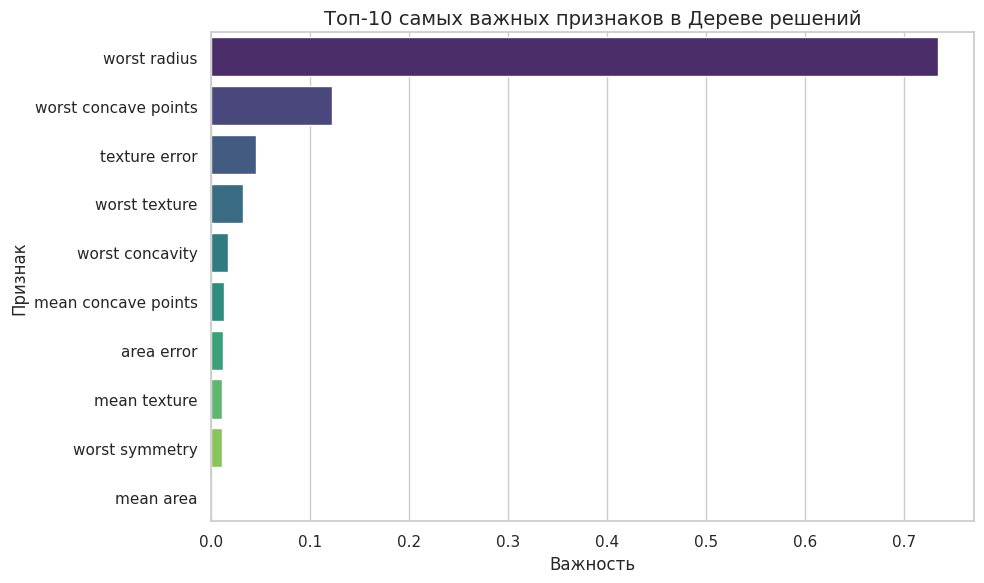

In [ ]:
# Получение важности признаков из обученного дерева
importances = tree_model.feature_importances_
feature_names = X.columns

# Создаем DataFrame для удобства сортировки
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Берем топ-10 признаков
top_10_features = feat_imp_df.head(10)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
plt.title('Топ-10 самых важных признаков в Дереве решений', fontsize=14)
plt.xlabel('Важность', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.show()

### 7. Визуализация дерева решений
Отобразим структуру обученного дерева решений. Так как мы ограничили глубину дерева (max_depth=4), граф получится читаемым.

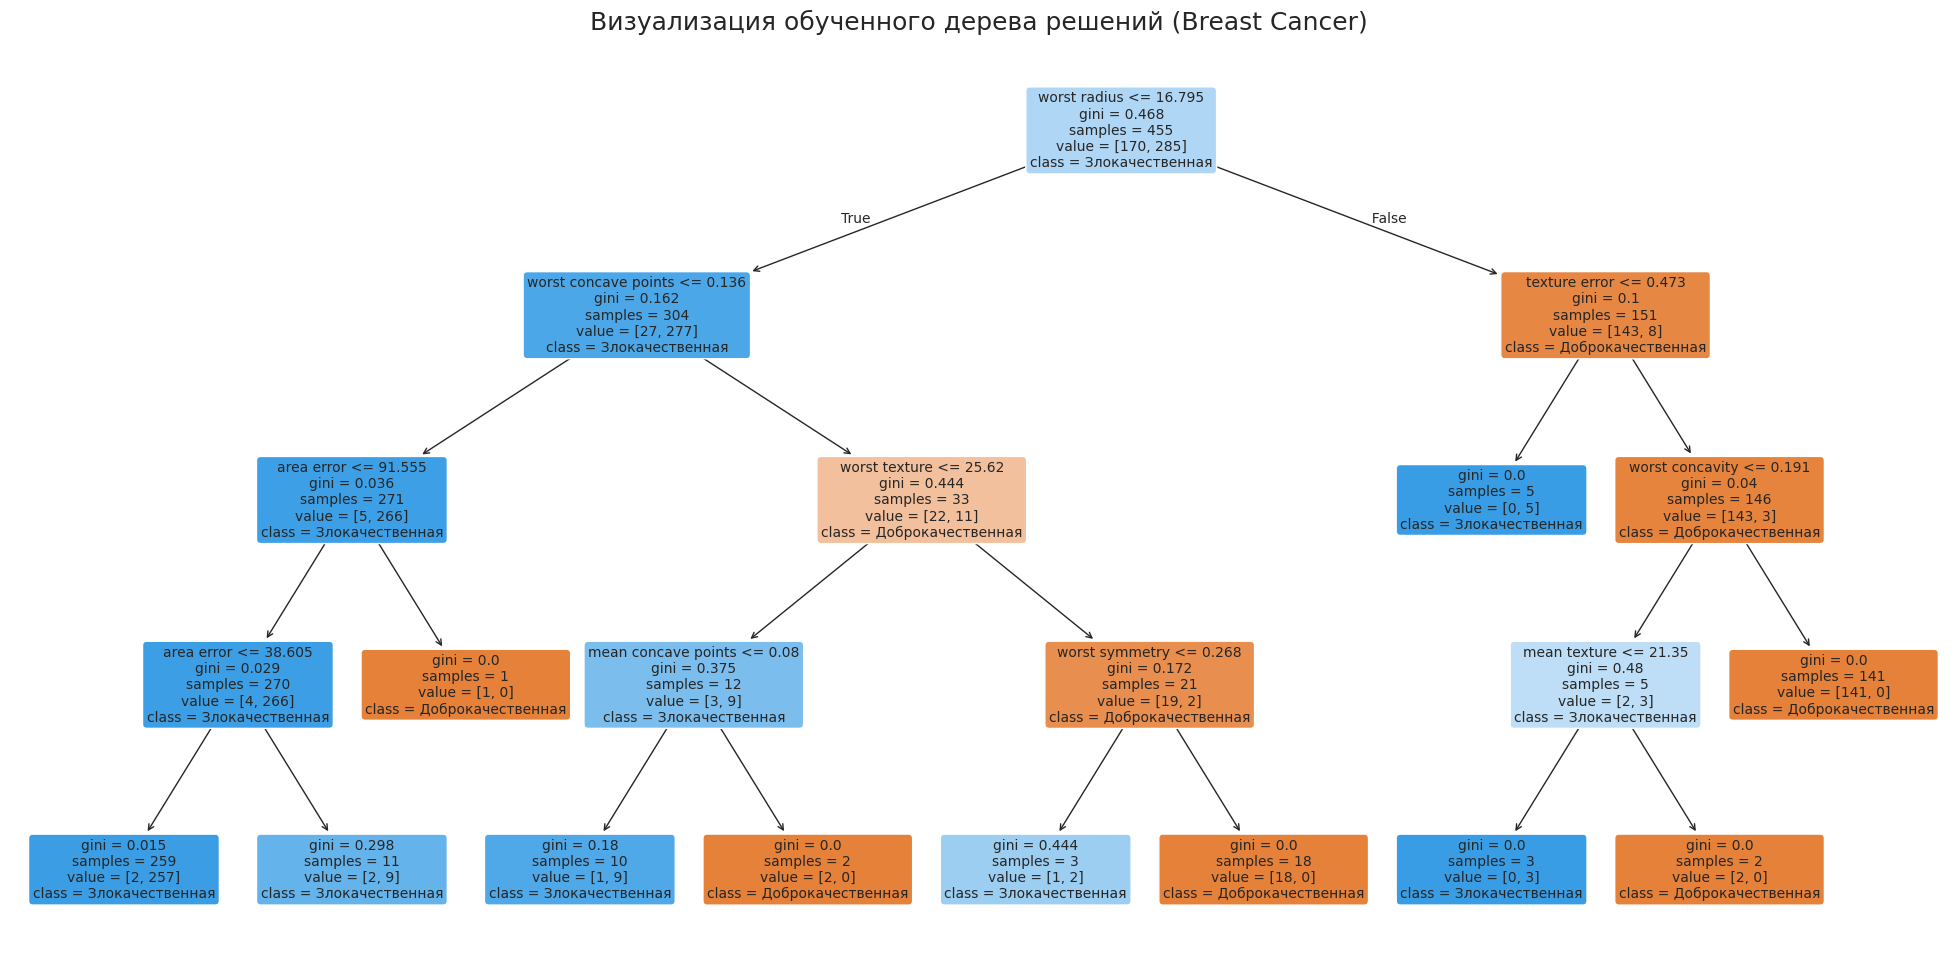

In [ ]:
plt.figure(figsize=(25, 12))
plot_tree(
    tree_model,
    feature_names=X.columns.tolist(),
    class_names=['Доброкачественная', 'Злокачественная'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Визуализация обученного дерева решений (Breast Cancer)', fontsize=18)
plt.show()

### Заключение
В ходе лабораторной работы был решен кейс по диагностике рака молочной железы.

Была проведена предобработка данных, обучены три алгоритма машинного обучения. Сравнительный анализ с помощью метрик Accuracy и F1-score показал, что все три модели справились с задачей на высоком уровне. Визуализация дерева решений и анализ важности признаков показали, что ключевыми факторами для диагностики являются характеристики размера опухоли. Цель лабораторной работы успешно достигнута.